# Bet Sizing

## Overview

This notebook demonstrates the public functions in `bet_sizing` using a compact synthetic event table.
- It converts classifier probabilities into discretized bet sizes.
- It converts target price discrepancies into dynamic bet sizes.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists())
sys.path.insert(0, str(root))

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
from src.model_backtesting.bet_sizing import (
    average_active_signals,
    discretize_signal,
    get_signal,
    get_target_position,
    get_w,
    limit_price,
)

## Probability-Based Bet Sizing

This cell defines the example inputs for probability-based sizing.
- `side` is the primary model direction, where `1` means long and `-1` means short.
- `prob` is the secondary model probability for taking the proposed bet.
- `pred` is the secondary model take/pass prediction, where `1` means trade and `0` means pass.

In [3]:
event_index = pd.date_range("2024-01-02 09:30", periods=12, freq="30min")

events = pd.DataFrame(
    {
        "t1": event_index + pd.to_timedelta([60, 90, 60, 120, 90, 60, 120, 90, 60, 120, 60, 90], unit="min"),
        "side": [1, 1, -1, 1, -1, 1, 1, -1, 1, -1, 1, 1],
    },
    index=event_index,
)

prob = pd.Series(
    [0.54, 0.61, 0.58, 0.73, 0.67, 0.52, 0.81, 0.64, 0.57, 0.76, 0.69, 0.55],
    index=event_index,
    name="prob",
)

pred = pd.Series(
    [1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1],
    index=event_index,
    name="pred",
)

display(pd.concat([events, prob, pred], axis=1))

,t1,side,prob,pred
2024-01-02 09:30:00,2024-01-02 10:30:00,1,0.54,1
2024-01-02 10:00:00,2024-01-02 11:30:00,1,0.61,1
2024-01-02 10:30:00,2024-01-02 11:30:00,-1,0.58,0
2024-01-02 11:00:00,2024-01-02 13:00:00,1,0.73,1
2024-01-02 11:30:00,2024-01-02 13:00:00,-1,0.67,1
2024-01-02 12:00:00,2024-01-02 13:00:00,1,0.52,0
2024-01-02 12:30:00,2024-01-02 14:30:00,1,0.81,1
2024-01-02 13:00:00,2024-01-02 14:30:00,-1,0.64,1
2024-01-02 13:30:00,2024-01-02 14:30:00,1,0.57,1
2024-01-02 14:00:00,2024-01-02 16:00:00,-1,0.76,1


This cell computes the intermediate signals for probability-based sizing.
- `confidence_signal` converts the predicted probability into a continuous size based on distance from random chance.
- `sized_signal` applies the secondary model take/pass prediction.
- `event_signal` applies the primary model side prediction.
- `averaged_signal` averages bets that are active at the same time.
- `discretized_signal` rounds the averaged active signal to the configured step size.
- `get_signal_output` is compared to verify the manual pipeline.

In [4]:
signal = get_signal(
    events=events,
    step_size=0.1,
    prob=prob,
    pred=pred,
    num_classes=2,
)

centered_signal = (prob - 1.0 / 2) / (prob * (1.0 - prob)) ** 0.5
confidence_signal = pd.Series(
    2 * norm.cdf(centered_signal),
    index=prob.index,
    name="confidence_signal",
) - 1
sized_signal = pred * confidence_signal
event_signal = sized_signal * events.loc[sized_signal.index, "side"]
event_signal.name = "event_signal"

active_signals = event_signal.to_frame("signal").join(events[["t1"]], how="left")
averaged_signal = average_active_signals(active_signals)
discretized_signal = discretize_signal(averaged_signal, step_size=0.1)

pipeline_steps = pd.concat(
    [
        prob.rename("prob"),
        pred.rename("pred"),
        events["side"],
        confidence_signal.rename("confidence_signal"),
        sized_signal.rename("sized_signal"),
        event_signal,
        averaged_signal.rename("averaged_signal"),
        discretized_signal.rename("discretized_signal"),
        signal.rename("get_signal_output"),
    ],
    axis=1,
)

pipeline_steps

,prob,pred,side,confidence_signal,sized_signal,event_signal,averaged_signal,discretized_signal,get_signal_output
2024-01-02 09:30:00,0.54,1.0,1.0,0.063967,0.063967,0.063967,0.063967,0.1,0.1
2024-01-02 10:00:00,0.61,1.0,1.0,0.178429,0.178429,0.178429,0.121198,0.1,0.1
2024-01-02 10:30:00,0.58,0.0,-1.0,0.128764,0.000000,-0.000000,0.089215,0.1,0.1
2024-01-02 11:00:00,0.73,1.0,1.0,0.395587,0.395587,0.395587,0.191339,0.2,0.2
2024-01-02 11:30:00,0.67,1.0,-1.0,0.282303,0.282303,-0.282303,0.056642,0.1,0.1
2024-01-02 12:00:00,0.52,0.0,1.0,0.031932,0.000000,0.000000,0.037761,0.0,0.0
2024-01-02 12:30:00,0.81,1.0,1.0,0.570595,0.570595,0.570595,0.170970,0.2,0.2
2024-01-02 13:00:00,0.64,1.0,-1.0,0.229459,0.229459,-0.229459,0.170568,0.2,0.2
2024-01-02 13:30:00,0.57,1.0,1.0,0.112440,0.112440,0.112440,0.151192,0.2,0.2
2024-01-02 14:00:00,0.76,1.0,-1.0,0.457330,0.457330,-0.457330,-0.000938,-0.0,-0.0


This cell visualizes the probability-based sizing results.
- The event signal shows the raw bet size assigned at event start times.
- The averaged active signal shows the overlap adjustment across currently active bets.
- The discretized signal is the final bet size after applying the step grid to reduce turnover.

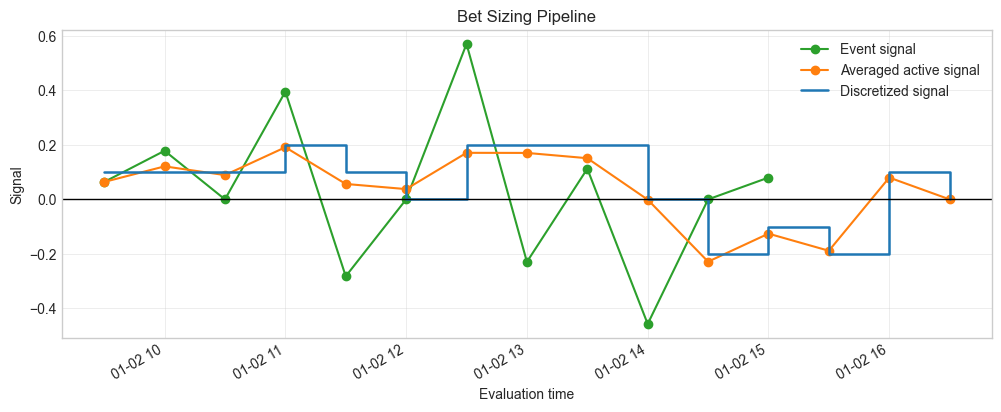

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(event_signal.index, event_signal, marker="o", label="Event signal", color="tab:green")
ax.plot(averaged_signal.index, averaged_signal, marker="o", label="Averaged active signal", color="tab:orange")
ax.step(discretized_signal.index, discretized_signal, where="post", label="Discretized signal", color="tab:blue",
        linewidth=1.8)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Bet Sizing Pipeline")
ax.set_ylabel("Signal")
ax.set_xlabel("Evaluation time")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.show()

## Target-Based Bet Sizing

This cell defines the example inputs for target-based sizing.
- `market_price` is the current executable price path.
- `forecast_price` is the model-implied future price used by the target-position rule.
- `divergence` is `forecast_price - market_price`, the input that drives the target position.

In [6]:
price_index = pd.date_range("2024-01-02 09:30", periods=20, freq="30min")

market_prices = pd.Series(
    [100.0, 101.0, 100.5, 99.8, 100.2, 101.5, 102.0, 101.2, 100.8, 101.1,
     102.3, 103.0, 102.7, 101.9, 101.5, 100.9, 100.4, 99.7, 99.2, 100.0],
    index=price_index,
    name="market_price",
)
forecast_prices = pd.Series(
    [103.0, 104.0, 102.0, 101.0, 99.0, 100.0, 105.0, 106.0, 104.0, 103.0,
     107.0, 108.0, 106.0, 105.0, 103.0, 101.0, 98.0, 97.0, 99.0, 102.0],
    index=price_index,
    name="forecast_price",
)

target_price_data = pd.concat(
    [
        market_prices,
        forecast_prices,
        (forecast_prices - market_prices).rename("divergence"),
    ],
    axis=1,
)

target_price_data

,market_price,forecast_price,divergence
2024-01-02 09:30:00,100.0,103.0,3.0
2024-01-02 10:00:00,101.0,104.0,3.0
2024-01-02 10:30:00,100.5,102.0,1.5
2024-01-02 11:00:00,99.8,101.0,1.2
2024-01-02 11:30:00,100.2,99.0,-1.2
2024-01-02 12:00:00,101.5,100.0,-1.5
2024-01-02 12:30:00,102.0,105.0,3.0
2024-01-02 13:00:00,101.2,106.0,4.8
2024-01-02 13:30:00,100.8,104.0,3.2
2024-01-02 14:00:00,101.1,103.0,1.9


This cell computes the target positions and rebalance prices for target-based sizing.
- `w` calibrates the sigmoid, in this case, a divergence of `10` maps to a bet size of `0.95`.
- `target_position` scales the continuous bet size by `max_position`.
- `current_position` is the position held before the rebalance.
- `order_size` is the trade required to move from `current_position` to `target_position`.
- `limit_price` averages inverse prices along the signed path from current to target position.

In [7]:
max_position = 100
w_params = {"divergence": 10, "m": 0.95}
w = get_w(w_params["divergence"], w_params["m"])

target_positions = pd.Series(
    [
        get_target_position(w, forecast_prices.loc[t], market_prices.loc[t], max_position)
        for t in price_index
    ],
    index=price_index,
    name="target_position",
)
current_positions = target_positions.shift(1).fillna(0).astype(int).rename("current_position")
order_sizes = (target_positions - current_positions).rename("order_size")

limit_prices = pd.Series(
    [
        limit_price(
            target_position=target_positions.loc[t],
            current_position=current_positions.loc[t],
            forecast_price=forecast_prices.loc[t],
            w=w,
            max_position=max_position,
        )
        for t in price_index
    ],
    index=price_index,
    name="limit_price",
)

target_sizing_path = pd.concat(
    [
        target_price_data,
        current_positions,
        target_positions,
        order_sizes,
        limit_prices,
    ],
    axis=1,
)

calibration_check = pd.Series(
    {
        "w": w,
        "example_target_position": get_target_position(w, 115, 100, max_position),
        "example_limit_price": limit_price(97, 0, 115, w, max_position),
    },
    name="target_sizing_calibration_check",
)

display(calibration_check)
target_sizing_path

w                           10.803324
example_target_position     97.000000
example_limit_price        112.365739
Name: target_sizing_calibration_check, dtype: float64

,market_price,forecast_price,divergence,current_position,target_position,order_size,limit_price
2024-01-02 09:30:00,100.0,103.0,3.0,0,67,67,101.713896
2024-01-02 10:00:00,101.0,104.0,3.0,67,67,0,NaN
2024-01-02 10:30:00,100.5,102.0,1.5,67,41,-26,99.882911
2024-01-02 11:00:00,99.8,101.0,1.2,41,34,-7,99.689913
2024-01-02 11:30:00,100.2,99.0,-1.2,34,-34,-68,99.017475
2024-01-02 12:00:00,101.5,100.0,-1.5,-34,-41,-7,101.351398
2024-01-02 12:30:00,102.0,105.0,3.0,-41,67,108,104.462863
2024-01-02 13:00:00,101.2,106.0,4.8,67,82,15,102.216357
2024-01-02 13:30:00,100.8,104.0,3.2,82,69,-13,100.230967
2024-01-02 14:00:00,101.1,103.0,1.9,69,50,-19,100.572141


This cell visualizes the target-based sizing results.
- The price chart compares market, forecast, and limit prices through time.
- The position chart shows current position, target position, and the order size needed to rebalance.
- For a long target, if the market price is at or below the limit price, the strategy can increase the long position toward the target; if the market price is above the limit price, the target long position should be reduced.
- For a short target, if the market price is at or above the limit price, the strategy can increase the short position toward the target; if the market price is below the limit price, the target short position should be reduced.

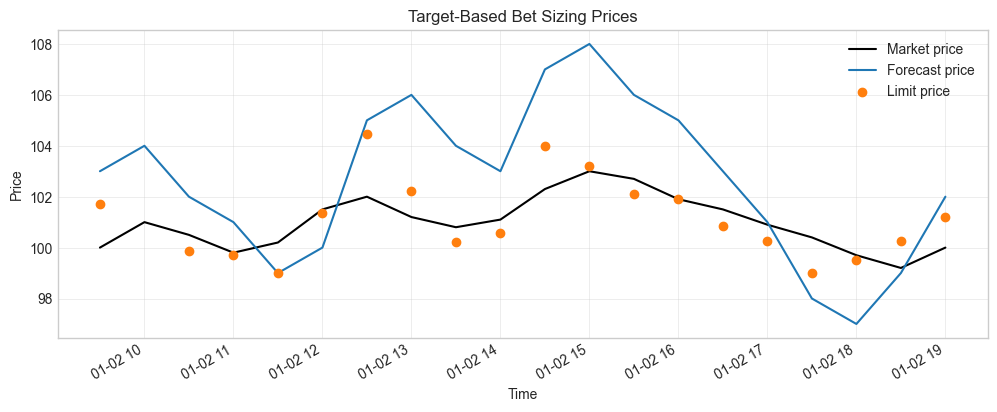

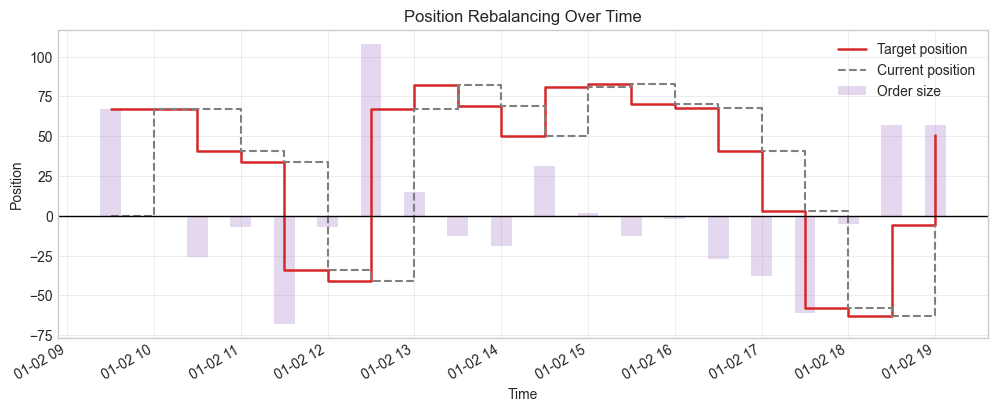

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(market_prices.index, market_prices, label="Market price", color="black", linewidth=1.5)
ax.plot(forecast_prices.index, forecast_prices, label="Forecast price", color="tab:blue", linewidth=1.5)
ax.scatter(limit_prices.index, limit_prices, label="Limit price", color="tab:orange", zorder=3)
ax.set_title("Target-Based Bet Sizing Prices")
ax.set_ylabel("Price")
ax.set_xlabel("Time")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.step(target_positions.index, target_positions, where="post", label="Target position", color="tab:red", linewidth=1.8)
ax.step(current_positions.index, current_positions, where="post", label="Current position", color="tab:gray",
        linestyle="--")
ax.bar(order_sizes.index, order_sizes, label="Order size", color="tab:purple", alpha=0.25, width=0.01)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Position Rebalancing Over Time")
ax.set_ylabel("Position")
ax.set_xlabel("Time")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.show()